# Week 4 - Strong Backbone: ResNet-18 / ResNet-34

Goals:
1. Load Week 2 metadata and pipeline config.
2. Build train/val/test dataloaders.
3. Define ResNet-18 / ResNet-34 backbones (scratch vs pretrained).
4. Train and compare variants on accuracy, precision, recall, and F1.
5. Save checkpoints, curves, confusion matrices, and summary metrics.

In [14]:
import os
import json
import time
import random
import pathlib
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import GTSRB
from torchvision.models import (
    resnet18, resnet34,
    ResNet18_Weights, ResNet34_Weights
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

try:
    from tqdm import tqdm
except ImportError:
    !pip -q install tqdm
    from tqdm import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [15]:
PROJECT_ROOT = pathlib.Path("/content/traffic-sign-classification")

DATA_ROOT = PROJECT_ROOT / "data"
META_ROOT = PROJECT_ROOT / "artifacts" / "metadata"
REPORT_ROOT = PROJECT_ROOT / "reports" / "week4"
CHECKPOINT_ROOT = pathlib.Path("/content/checkpoints_week4")

for p in [DATA_ROOT, META_ROOT, REPORT_ROOT, CHECKPOINT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("REPORT_ROOT:", REPORT_ROOT)
print("CHECKPOINT_ROOT:", CHECKPOINT_ROOT)

PROJECT_ROOT: /content/traffic-sign-classification
DATA_ROOT: /content/traffic-sign-classification/data
REPORT_ROOT: /content/traffic-sign-classification/reports/week4
CHECKPOINT_ROOT: /content/checkpoints_week4


In [16]:
# Optional: sanity-check that data is present
tv_train = GTSRB(root=str(DATA_ROOT), split="train", download=True)
tv_test = GTSRB(root=str(DATA_ROOT), split="test", download=True)

print("Torchvision train size:", len(tv_train))
print("Torchvision test size:", len(tv_test))

# Load Week 2 metadata
train_df = pd.read_csv(META_ROOT / "train_metadata_full.csv")
test_df = pd.read_csv(META_ROOT / "test_metadata_full.csv")

# Load pipeline config from Week 2
with open(META_ROOT / "week2_pipeline_config.json", "r") as f:
    pipeline_config = json.load(f)

train_meta = train_df[train_df["split"] == "train"].reset_index(drop=True)
val_meta = train_df[train_df["split"] == "val"].reset_index(drop=True)

print("Train rows:", len(train_meta))
print("Val rows:", len(val_meta))
print("Test rows:", len(test_df))
print(json.dumps(pipeline_config, indent=2))

Torchvision train size: 26640
Torchvision test size: 12630
Train rows: 23976
Val rows: 2664
Test rows: 12630
{
  "seed": 42,
  "image_size": 64,
  "batch_size": 128,
  "use_roi_crop": true,
  "preprocessing": "clahe",
  "pad_ratio": 0.08,
  "mean": [
    0.48077961802482605,
    0.4455212652683258,
    0.45868155360221863
  ],
  "std": [
    0.2539152204990387,
    0.2469169795513153,
    0.25597625970840454
  ]
}


In [17]:
from pathlib import Path
import pandas as pd
from torch.utils.data import DataLoader

gtsrb_root = DATA_ROOT / "gtsrb"
test_csv = gtsrb_root / "GT-final_test.csv"
test_img_dir = gtsrb_root / "GTSRB" / "Final_Test" / "Images"

test_df_raw = pd.read_csv(test_csv, sep=";")

rename_map = {}
for col in test_df_raw.columns:
    c = col.strip().lower()
    if c == "filename":
        rename_map[col] = "filename"
    elif c == "width":
        rename_map[col] = "width"
    elif c == "height":
        rename_map[col] = "height"
    elif c in ["roi.x1", "roi_x1"]:
        rename_map[col] = "roi_x1"
    elif c in ["roi.y1", "roi_y1"]:
        rename_map[col] = "roi_y1"
    elif c in ["roi.x2", "roi_x2"]:
        rename_map[col] = "roi_x2"
    elif c in ["roi.y2", "roi_y2"]:
        rename_map[col] = "roi_y2"
    elif c == "classid":
        rename_map[col] = "label"

test_df = test_df_raw.rename(columns=rename_map)
test_df["image_path"] = test_df["filename"].apply(lambda x: str((test_img_dir / x).resolve()))
test_df["split"] = "test"

required_cols = ["image_path", "label", "roi_x1", "roi_y1", "roi_x2", "roi_y2"]
missing = [c for c in required_cols if c not in test_df.columns]
print("Missing columns:", missing)
print(test_df.columns)

Missing columns: []
Index(['filename', 'width', 'height', 'roi_x1', 'roi_y1', 'roi_x2', 'roi_y2',
       'label', 'image_path', 'split'],
      dtype='object')


In [18]:
import sys
sys.path.append(str(PROJECT_ROOT))

from src.datasets import GTSRBCustomDataset

NUM_CLASSES = 43

IMG_SIZE = int(pipeline_config["image_size"])
MEAN = pipeline_config["mean"]
STD = pipeline_config["std"]

USE_ROI_CROP = bool(pipeline_config["use_roi_crop"])
PREPROCESSING = pipeline_config["preprocessing"]   # "none", "equalize", "clahe"
PAD_RATIO = float(pipeline_config["pad_ratio"])

BATCH_SIZE = 128

print("IMG_SIZE:", IMG_SIZE)
print("PREPROCESSING:", PREPROCESSING)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(
        degrees=10,
        translate=(0.10, 0.10),
        scale=(0.9, 1.1)
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

train_ds = GTSRBCustomDataset(
    train_meta,
    transform=train_transform,
    use_roi_crop=USE_ROI_CROP,
    preprocessing=PREPROCESSING,
    pad_ratio=PAD_RATIO
)

val_ds = GTSRBCustomDataset(
    val_meta,
    transform=eval_transform,
    use_roi_crop=USE_ROI_CROP,
    preprocessing=PREPROCESSING,
    pad_ratio=PAD_RATIO
)

test_ds = GTSRBCustomDataset(
    test_df,
    transform=eval_transform,
    use_roi_crop=USE_ROI_CROP,
    preprocessing=PREPROCESSING,
    pad_ratio=PAD_RATIO
)

print(len(train_ds), len(val_ds), len(test_ds))

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

x, y = next(iter(train_loader))
print("x shape:", x.shape)
print("y shape:", y.shape)
print("label range:", int(y.min()), int(y.max()))

IMG_SIZE: 64
PREPROCESSING: clahe
23976 2664 12630
Train batches: 188
Val batches: 21
Test batches: 99
x shape: torch.Size([128, 3, 64, 64])
y shape: torch.Size([128])
label range: 1 42


In [19]:
def create_resnet_model(arch: str, num_classes: int, pretrained: bool) -> nn.Module:
    """
    arch: "resnet18" or "resnet34"
    pretrained: if True, use ImageNet weights; else random init.
    """
    if arch == "resnet18":
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        model = resnet18(weights=weights)
    elif arch == "resnet34":
        weights = ResNet34_Weights.DEFAULT if pretrained else None
        model = resnet34(weights=weights)
    else:
        raise ValueError(f"Unsupported arch: {arch}")

    # Replace final fully connected layer for 43 classes
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model

In [20]:
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
model_test = create_resnet_model("resnet18", NUM_CLASSES, pretrained=False)
with torch.no_grad():
    out = model_test(dummy)
print(model_test.__class__.__name__)
print("Output shape:", out.shape)

ResNet
Output shape: torch.Size([2, 43])


In [21]:
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "accuracy": float(acc),
        "precision_macro": float(precision),
        "recall_macro": float(recall),
        "f1_macro": float(f1)
    }

In [22]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_targets = []

    for images, targets in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = logits.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(targets.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_targets, all_preds)
    return epoch_loss, metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_targets = []

    for images, targets in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, targets)

        running_loss += loss.item() * images.size(0)

        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy().tolist())
        all_targets.extend(targets.cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_targets, all_preds)
    return epoch_loss, metrics, np.array(all_targets), np.array(all_preds)

In [23]:
def save_checkpoint(path, model, optimizer, epoch, history, best_score):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "best_score": best_score
    }, path)

In [24]:
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 5

experiments = [
    {"name": "resnet18_scratch",   "arch": "resnet18", "pretrained": False},
    {"name": "resnet18_pretrained","arch": "resnet18", "pretrained": True},
    {"name": "resnet34_scratch",   "arch": "resnet34", "pretrained": False},
    {"name": "resnet34_pretrained","arch": "resnet34", "pretrained": True},
]

print("Planned experiments:")
for exp in experiments:
    print(exp)

Planned experiments:
{'name': 'resnet18_scratch', 'arch': 'resnet18', 'pretrained': False}
{'name': 'resnet18_pretrained', 'arch': 'resnet18', 'pretrained': True}
{'name': 'resnet34_scratch', 'arch': 'resnet34', 'pretrained': False}
{'name': 'resnet34_pretrained', 'arch': 'resnet34', 'pretrained': True}


Starting experiment: resnet18_scratch (arch=resnet18, pretrained=False)


[resnet18_scratch] Epoch 01/20 | train_loss=0.8343 | val_loss=0.1295 | train_acc=0.7530 | val_acc=0.9557 | val_f1=0.9503 | lr=0.001000
[resnet18_scratch] Saved new best checkpoint at epoch 1.


[resnet18_scratch] Epoch 02/20 | train_loss=0.1537 | val_loss=0.1016 | train_acc=0.9509 | val_acc=0.9688 | val_f1=0.9666 | lr=0.001000
[resnet18_scratch] Saved new best checkpoint at epoch 2.


[resnet18_scratch] Epoch 03/20 | train_loss=0.0894 | val_loss=0.0744 | train_acc=0.9714 | val_acc=0.9801 | val_f1=0.9830 | lr=0.001000
[resnet18_scratch] Saved new best checkpoint at epoch 3.


[resnet18_scratch] Epoch 04/20 | train_loss=0.0732 | val_loss=0.0244 | train_acc=0.9766 | val_acc=0.9906 | val_f1=0.9915 | lr=0.001000
[resnet18_scratch] Saved new best checkpoint at epoch 4.


...

[resnet18_scratch] Epoch 11/20 | train_loss=0.0123 | val_loss=0.0113 | train_acc=0.9958 | val_acc=0.9966 | val_f1=0.9935 | lr=0.000500
[resnet18_scratch] No improvement. Patience: 1/5


[resnet18_scratch] Epoch 12/20 | train_loss=0.0085 | val_loss=0.0107 | train_acc=0.9970 | val_acc=0.9974 | val_f1=0.9966 | lr=0.000500
[resnet18_scratch] No improvement. Patience: 2/5


[resnet18_scratch] Epoch 13/20 | train_loss=0.0134 | val_loss=0.0062 | train_acc=0.9955 | val_acc=0.9974 | val_f1=0.9960 | lr=0.000250
[resnet18_scratch] No improvement. Patience: 3/5


[resnet18_scratch] Epoch 14/20 | train_loss=0.0055 | val_loss=0.0060 | train_acc=0.9983 | val_acc=0.9977 | val_f1=0.9971 | lr=0.000250
[resnet18_scratch] No improvement. Patience: 4/5


[resnet18_scratch] Epoch 15/20 | train_loss=0.0043 | val_loss=0.0123 | train_acc=0.9987 | val_acc=0.9966 | val_f1=0.9944 | lr=0.000250
[resnet18_scratch] No improvement. Patience: 5/5
[resnet18_scratch] Early stopping triggered.
[resnet18_scratch] Saved history CSV: /content/traffic-sign-classification/reports/week4/resnet18_scratch_history.csv


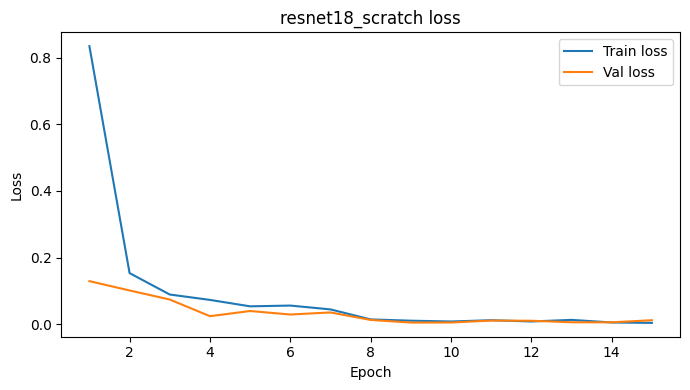

[resnet18_scratch] Saved loss curve: /content/traffic-sign-classification/reports/week4/resnet18_scratch_loss_curve.png


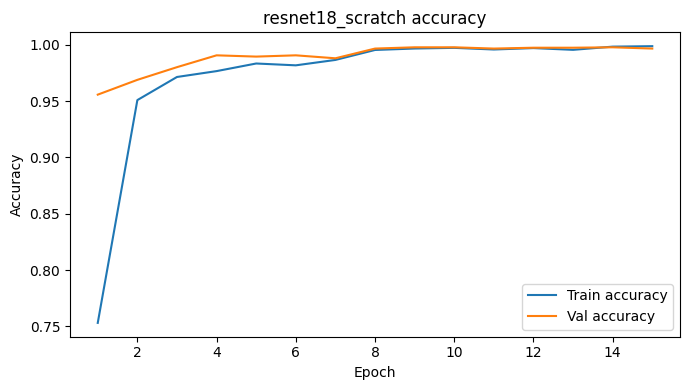

[resnet18_scratch] Saved accuracy curve: /content/traffic-sign-classification/reports/week4/resnet18_scratch_accuracy_curve.png
[resnet18_scratch] Loaded best checkpoint from epoch 10 with best F1=0.9972


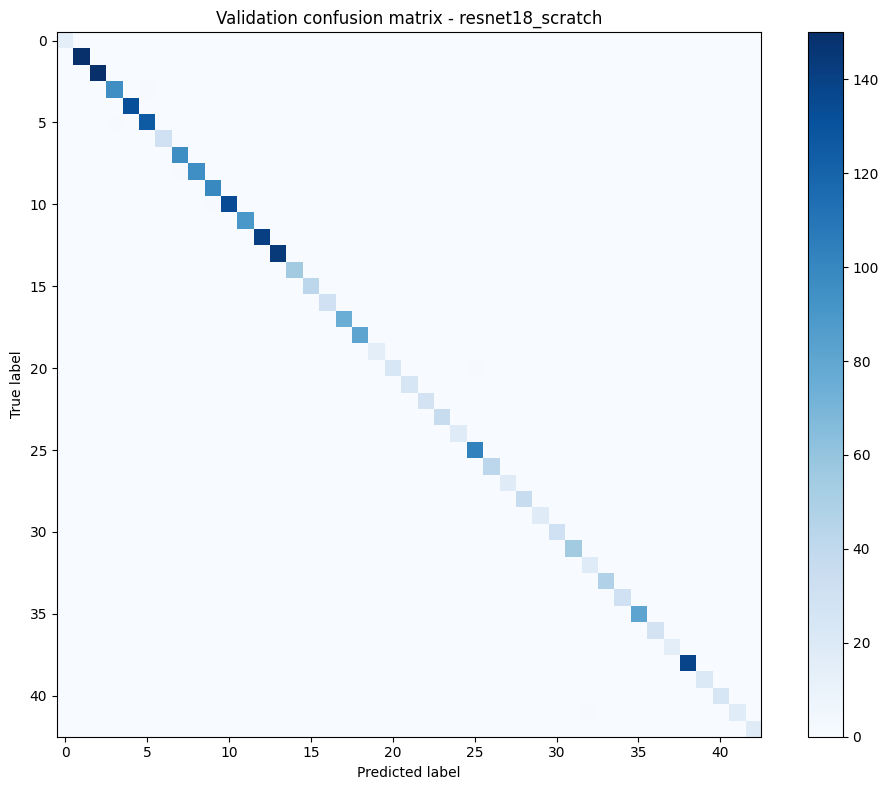

[resnet18_scratch] Saved val confusion matrix: /content/traffic-sign-classification/reports/week4/resnet18_scratch_val_confusion_matrix.png
[resnet18_scratch] Saved val classification report: /content/traffic-sign-classification/reports/week4/resnet18_scratch_val_classification_report.csv
Starting experiment: resnet18_pretrained (arch=resnet18, pretrained=True)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


[resnet18_pretrained] Epoch 01/20 | train_loss=0.4058 | val_loss=0.0554 | train_acc=0.8778 | val_acc=0.9835 | val_f1=0.9767 | lr=0.001000
[resnet18_pretrained] Saved new best checkpoint at epoch 1.


[resnet18_pretrained] Epoch 02/20 | train_loss=0.0804 | val_loss=0.0810 | train_acc=0.9757 | val_acc=0.9805 | val_f1=0.9692 | lr=0.001000
[resnet18_pretrained] No improvement. Patience: 1/5


[resnet18_pretrained] Epoch 03/20 | train_loss=0.0709 | val_loss=0.0541 | train_acc=0.9791 | val_acc=0.9857 | val_f1=0.9893 | lr=0.001000
[resnet18_pretrained] Saved new best checkpoint at epoch 3.


...

[resnet18_pretrained] Epoch 14/20 | train_loss=0.0075 | val_loss=0.0043 | train_acc=0.9975 | val_acc=0.9992 | val_f1=0.9985 | lr=0.000500
[resnet18_pretrained] No improvement. Patience: 1/5


[resnet18_pretrained] Epoch 15/20 | train_loss=0.0122 | val_loss=0.0078 | train_acc=0.9967 | val_acc=0.9989 | val_f1=0.9972 | lr=0.000500
[resnet18_pretrained] No improvement. Patience: 2/5


[resnet18_pretrained] Epoch 16/20 | train_loss=0.0108 | val_loss=0.0071 | train_acc=0.9966 | val_acc=0.9981 | val_f1=0.9986 | lr=0.000250
[resnet18_pretrained] No improvement. Patience: 3/5


[resnet18_pretrained] Epoch 17/20 | train_loss=0.0031 | val_loss=0.0050 | train_acc=0.9991 | val_acc=0.9985 | val_f1=0.9988 | lr=0.000250
[resnet18_pretrained] No improvement. Patience: 4/5


[resnet18_pretrained] Epoch 18/20 | train_loss=0.0022 | val_loss=0.0061 | train_acc=0.9995 | val_acc=0.9989 | val_f1=0.9990 | lr=0.000250
[resnet18_pretrained] No improvement. Patience: 5/5
[resnet18_pretrained] Early stopping triggered.
[resnet18_pretrained] Saved history CSV: /content/traffic-sign-classification/reports/week4/resnet18_pretrained_history.csv


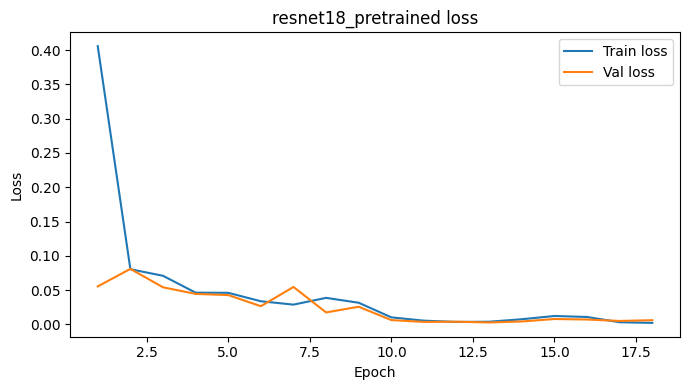

[resnet18_pretrained] Saved loss curve: /content/traffic-sign-classification/reports/week4/resnet18_pretrained_loss_curve.png


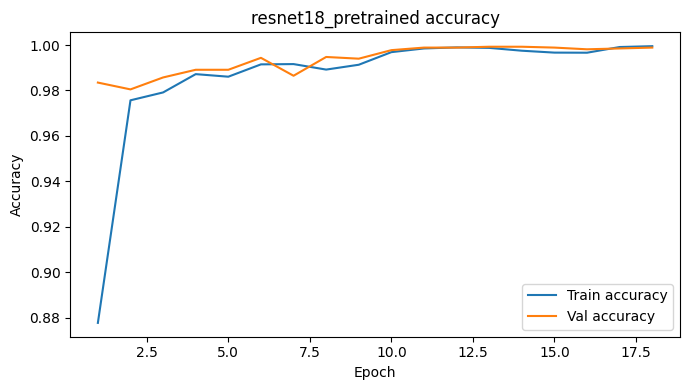

[resnet18_pretrained] Saved accuracy curve: /content/traffic-sign-classification/reports/week4/resnet18_pretrained_accuracy_curve.png
[resnet18_pretrained] Loaded best checkpoint from epoch 13 with best F1=0.9992


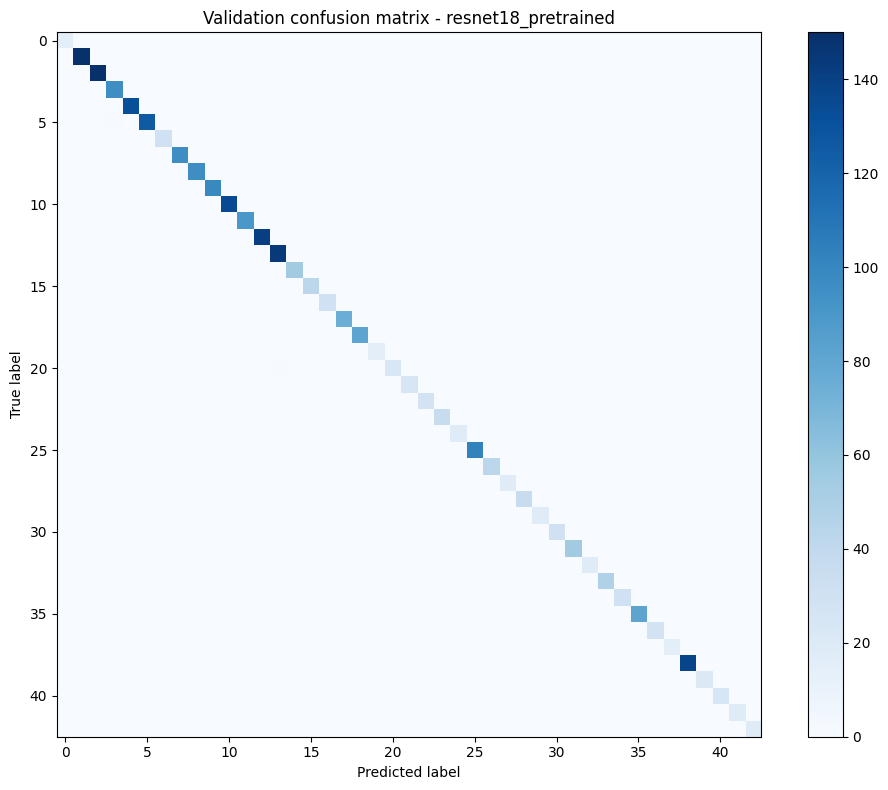

[resnet18_pretrained] Saved val confusion matrix: /content/traffic-sign-classification/reports/week4/resnet18_pretrained_val_confusion_matrix.png
[resnet18_pretrained] Saved val classification report: /content/traffic-sign-classification/reports/week4/resnet18_pretrained_val_classification_report.csv
Starting experiment: resnet34_scratch (arch=resnet34, pretrained=False)


[resnet34_scratch] Epoch 01/20 | train_loss=1.1789 | val_loss=0.4828 | train_acc=0.6469 | val_acc=0.8634 | val_f1=0.8344 | lr=0.001000
[resnet34_scratch] Saved new best checkpoint at epoch 1.


[resnet34_scratch] Epoch 02/20 | train_loss=0.2135 | val_loss=0.0853 | train_acc=0.9334 | val_acc=0.9707 | val_f1=0.9638 | lr=0.001000
[resnet34_scratch] Saved new best checkpoint at epoch 2.


[resnet34_scratch] Epoch 03/20 | train_loss=0.1267 | val_loss=0.1470 | train_acc=0.9608 | val_acc=0.9497 | val_f1=0.9399 | lr=0.001000
[resnet34_scratch] No improvement. Patience: 1/5


[resnet34_scratch] Epoch 04/20 | train_loss=0.0836 | val_loss=0.2965 | train_acc=0.9740 | val_acc=0.9152 | val_f1=0.9323 | lr=0.001000
[resnet34_scratch] No improvement. Patience: 2/5


...

[resnet34_scratch] Epoch 16/20 | train_loss=0.0061 | val_loss=0.0096 | train_acc=0.9980 | val_acc=0.9981 | val_f1=0.9980 | lr=0.000500
[resnet34_scratch] Saved new best checkpoint at epoch 16.


[resnet34_scratch] Epoch 17/20 | train_loss=0.0151 | val_loss=0.0066 | train_acc=0.9953 | val_acc=0.9981 | val_f1=0.9966 | lr=0.000500
[resnet34_scratch] No improvement. Patience: 1/5


[resnet34_scratch] Epoch 18/20 | train_loss=0.0111 | val_loss=0.0073 | train_acc=0.9965 | val_acc=0.9974 | val_f1=0.9968 | lr=0.000500
[resnet34_scratch] No improvement. Patience: 2/5


[resnet34_scratch] Epoch 19/20 | train_loss=0.0136 | val_loss=0.0054 | train_acc=0.9962 | val_acc=0.9977 | val_f1=0.9962 | lr=0.000250
[resnet34_scratch] No improvement. Patience: 3/5


[resnet34_scratch] Epoch 20/20 | train_loss=0.0052 | val_loss=0.0061 | train_acc=0.9981 | val_acc=0.9981 | val_f1=0.9981 | lr=0.000250
[resnet34_scratch] Saved new best checkpoint at epoch 20.
[resnet34_scratch] Saved history CSV: /content/traffic-sign-classification/reports/week4/resnet34_scratch_history.csv


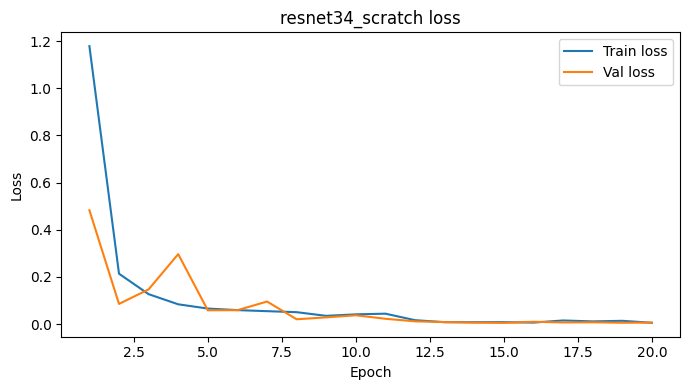

[resnet34_scratch] Saved loss curve: /content/traffic-sign-classification/reports/week4/resnet34_scratch_loss_curve.png


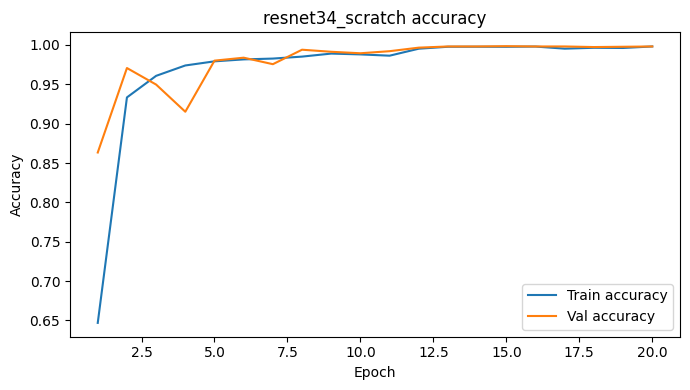

[resnet34_scratch] Saved accuracy curve: /content/traffic-sign-classification/reports/week4/resnet34_scratch_accuracy_curve.png
[resnet34_scratch] Loaded best checkpoint from epoch 20 with best F1=0.9981


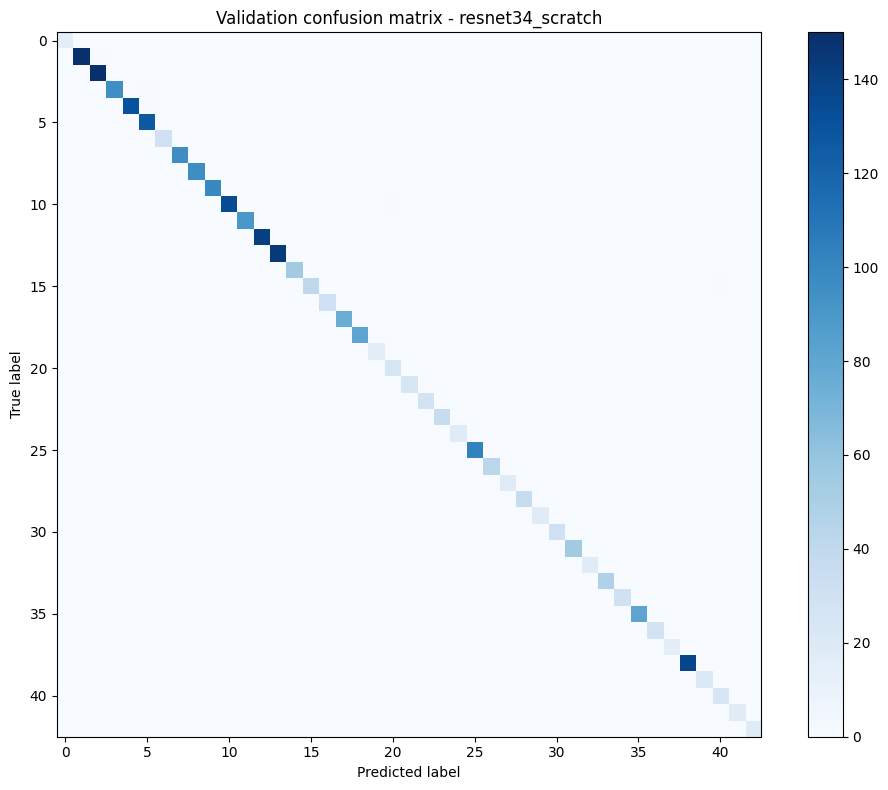

[resnet34_scratch] Saved val confusion matrix: /content/traffic-sign-classification/reports/week4/resnet34_scratch_val_confusion_matrix.png
[resnet34_scratch] Saved val classification report: /content/traffic-sign-classification/reports/week4/resnet34_scratch_val_classification_report.csv
Starting experiment: resnet34_pretrained (arch=resnet34, pretrained=True)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 212MB/s]


[resnet34_pretrained] Epoch 01/20 | train_loss=0.4355 | val_loss=0.1206 | train_acc=0.8703 | val_acc=0.9647 | val_f1=0.9543 | lr=0.001000
[resnet34_pretrained] Saved new best checkpoint at epoch 1.


[resnet34_pretrained] Epoch 02/20 | train_loss=0.0950 | val_loss=0.0978 | train_acc=0.9725 | val_acc=0.9718 | val_f1=0.9574 | lr=0.001000
[resnet34_pretrained] Saved new best checkpoint at epoch 2.


[resnet34_pretrained] Epoch 03/20 | train_loss=0.0680 | val_loss=0.0458 | train_acc=0.9806 | val_acc=0.9861 | val_f1=0.9803 | lr=0.001000
[resnet34_pretrained] Saved new best checkpoint at epoch 3.


...

[resnet34_pretrained] Epoch 12/20 | train_loss=0.0050 | val_loss=0.0065 | train_acc=0.9985 | val_acc=0.9981 | val_f1=0.9974 | lr=0.000500
[resnet34_pretrained] No improvement. Patience: 1/5


[resnet34_pretrained] Epoch 13/20 | train_loss=0.0025 | val_loss=0.0059 | train_acc=0.9992 | val_acc=0.9989 | val_f1=0.9990 | lr=0.000500
[resnet34_pretrained] No improvement. Patience: 2/5


[resnet34_pretrained] Epoch 14/20 | train_loss=0.0039 | val_loss=0.0055 | train_acc=0.9990 | val_acc=0.9989 | val_f1=0.9992 | lr=0.000250
[resnet34_pretrained] No improvement. Patience: 3/5


[resnet34_pretrained] Epoch 15/20 | train_loss=0.0024 | val_loss=0.0044 | train_acc=0.9993 | val_acc=0.9989 | val_f1=0.9994 | lr=0.000250
[resnet34_pretrained] No improvement. Patience: 4/5


[resnet34_pretrained] Epoch 16/20 | train_loss=0.0017 | val_loss=0.0043 | train_acc=0.9996 | val_acc=0.9992 | val_f1=0.9987 | lr=0.000250
[resnet34_pretrained] No improvement. Patience: 5/5
[resnet34_pretrained] Early stopping triggered.
[resnet34_pretrained] Saved history CSV: /content/traffic-sign-classification/reports/week4/resnet34_pretrained_history.csv


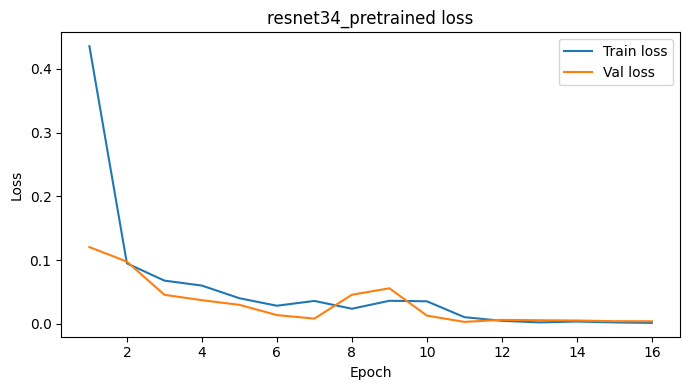

[resnet34_pretrained] Saved loss curve: /content/traffic-sign-classification/reports/week4/resnet34_pretrained_loss_curve.png


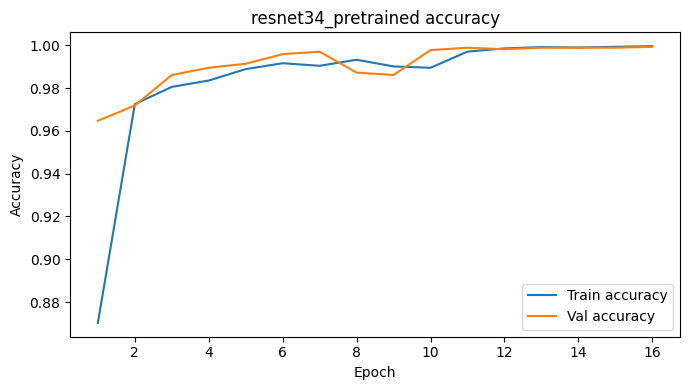

[resnet34_pretrained] Saved accuracy curve: /content/traffic-sign-classification/reports/week4/resnet34_pretrained_accuracy_curve.png
[resnet34_pretrained] Loaded best checkpoint from epoch 11 with best F1=0.9994


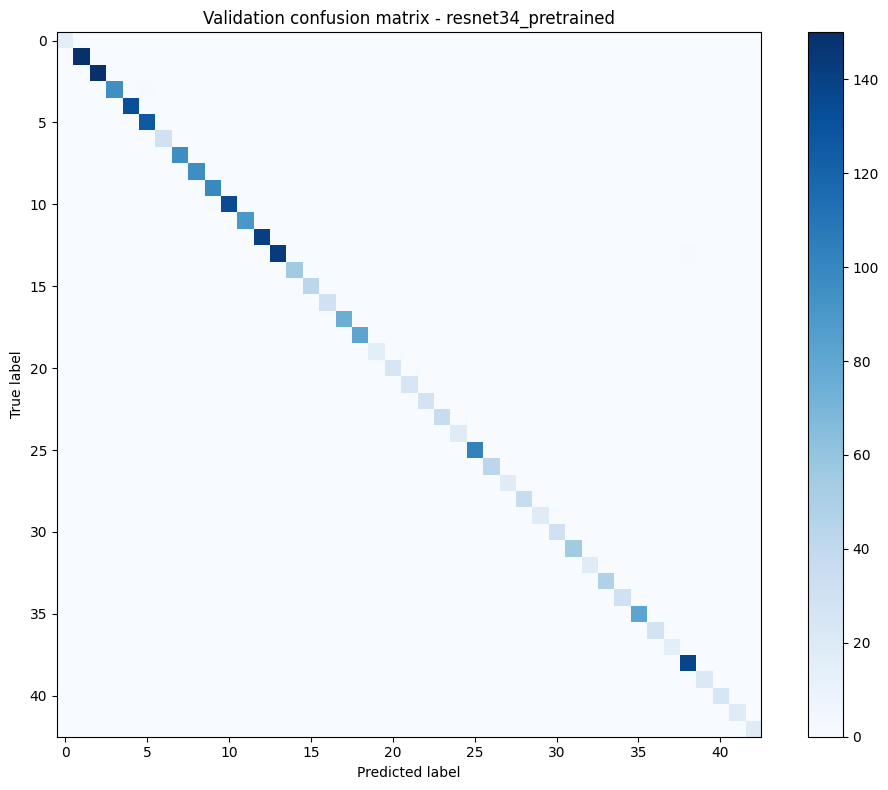

[resnet34_pretrained] Saved val confusion matrix: /content/traffic-sign-classification/reports/week4/resnet34_pretrained_val_confusion_matrix.png
[resnet34_pretrained] Saved val classification report: /content/traffic-sign-classification/reports/week4/resnet34_pretrained_val_classification_report.csv
Finished all experiments.


In [25]:
criterion = nn.CrossEntropyLoss()

all_results = []

for exp in experiments:
    exp_name = exp["name"]
    arch = exp["arch"]
    pretrained = exp["pretrained"]

    print("=" * 80)
    print(f"Starting experiment: {exp_name} (arch={arch}, pretrained={pretrained})")
    print("=" * 80)

    model = create_resnet_model(arch, NUM_CLASSES, pretrained=pretrained).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    history = []
    best_val_f1 = -1.0
    best_epoch = -1
    patience_counter = 0

    best_ckpt_path = CHECKPOINT_ROOT / f"{exp_name}_best.pth"
    last_ckpt_path = CHECKPOINT_ROOT / f"{exp_name}_last.pth"

    for epoch in range(1, NUM_EPOCHS + 1):
        start_time = time.time()

        train_loss, train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE
        )

        val_loss, val_metrics, y_val_true, y_val_pred = evaluate(
            model, val_loader, criterion, DEVICE
        )

        scheduler.step(val_metrics["f1_macro"])

        epoch_time = time.time() - start_time
        lr_now = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": epoch,
            "lr": lr_now,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_accuracy": train_metrics["accuracy"],
            "train_precision_macro": train_metrics["precision_macro"],
            "train_recall_macro": train_metrics["recall_macro"],
            "train_f1_macro": train_metrics["f1_macro"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision_macro": val_metrics["precision_macro"],
            "val_recall_macro": val_metrics["recall_macro"],
            "val_f1_macro": val_metrics["f1_macro"],
            "epoch_time_sec": epoch_time
        }
        history.append(row)

        print(
            f"[{exp_name}] Epoch {epoch:02d}/{NUM_EPOCHS} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"train_acc={train_metrics['accuracy']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_f1={val_metrics['f1_macro']:.4f} | lr={lr_now:.6f}"
        )

        # Save "last" checkpoint
        save_checkpoint(last_ckpt_path, model, optimizer, epoch, history, best_val_f1)

        # Save best model by val F1
        if val_metrics["f1_macro"] > best_val_f1:
            best_val_f1 = val_metrics["f1_macro"]
            best_epoch = epoch
            patience_counter = 0
            save_checkpoint(best_ckpt_path, model, optimizer, epoch, history, best_val_f1)
            print(f"[{exp_name}] Saved new best checkpoint at epoch {epoch}.")
        else:
            patience_counter += 1
            print(f"[{exp_name}] No improvement. Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}")

        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"[{exp_name}] Early stopping triggered.")
            break

    # Save history CSV
    history_df = pd.DataFrame(history)
    history_csv_path = REPORT_ROOT / f"{exp_name}_history.csv"
    history_df.to_csv(history_csv_path, index=False)
    print(f"[{exp_name}] Saved history CSV:", history_csv_path)

    # Plot and save loss curve
    plt.figure(figsize=(7, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{exp_name} loss")
    plt.legend()
    plt.tight_layout()
    loss_plot_path = REPORT_ROOT / f"{exp_name}_loss_curve.png"
    plt.savefig(loss_plot_path, dpi=200)
    plt.show()
    print(f"[{exp_name}] Saved loss curve:", loss_plot_path)

    # Plot and save accuracy curve
    plt.figure(figsize=(7, 4))
    plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train accuracy")
    plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{exp_name} accuracy")
    plt.legend()
    plt.tight_layout()
    acc_plot_path = REPORT_ROOT / f"{exp_name}_accuracy_curve.png"
    plt.savefig(acc_plot_path, dpi=200)
    plt.show()
    print(f"[{exp_name}] Saved accuracy curve:", acc_plot_path)

    # Reload best checkpoint and compute final val & test metrics
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"[{exp_name}] Loaded best checkpoint from epoch {ckpt['epoch']} with best F1={ckpt['best_score']:.4f}")

    val_loss, val_metrics, y_val_true, y_val_pred = evaluate(
        model, val_loader, criterion, DEVICE
    )
    test_loss, test_metrics, y_test_true, y_test_pred = evaluate(
        model, test_loader, criterion, DEVICE
    )

    # Save confusion matrix and classification report for validation
    cm_val = confusion_matrix(y_val_true, y_val_pred, labels=list(range(NUM_CLASSES)))
    plt.figure(figsize=(10, 8))
    plt.imshow(cm_val, interpolation="nearest", cmap="Blues")
    plt.title(f"Validation confusion matrix - {exp_name}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.colorbar()
    plt.tight_layout()
    cm_path = REPORT_ROOT / f"{exp_name}_val_confusion_matrix.png"
    plt.savefig(cm_path, dpi=200)
    plt.show()
    print(f"[{exp_name}] Saved val confusion matrix:", cm_path)

    report_dict = classification_report(
        y_val_true,
        y_val_pred,
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report_dict).transpose()
    report_csv_path = REPORT_ROOT / f"{exp_name}_val_classification_report.csv"
    report_df.to_csv(report_csv_path, index=True)
    print(f"[{exp_name}] Saved val classification report:", report_csv_path)

    # Store summary
    result_entry = {
        "experiment": exp_name,
        "arch": arch,
        "pretrained": pretrained,
        "best_epoch": int(ckpt["epoch"]),
        "val_loss": float(val_loss),
        "val_accuracy": float(val_metrics["accuracy"]),
        "val_precision_macro": float(val_metrics["precision_macro"]),
        "val_recall_macro": float(val_metrics["recall_macro"]),
        "val_f1_macro": float(val_metrics["f1_macro"]),
        "test_loss": float(test_loss),
        "test_accuracy": float(test_metrics["accuracy"]),
        "test_precision_macro": float(test_metrics["precision_macro"]),
        "test_recall_macro": float(test_metrics["recall_macro"]),
        "test_f1_macro": float(test_metrics["f1_macro"]),
    }
    all_results.append(result_entry)

print("Finished all experiments.")

In [26]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(by="val_f1_macro", ascending=False)
results_df

,experiment,arch,pretrained,best_epoch,val_loss,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,test_loss,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
3,resnet34_pretrained,resnet34,True,11,0.003305,0.998874,0.999417,0.999424,0.999418,0.043403,0.988044,0.983970,0.980860,0.981527
1,resnet18_pretrained,resnet18,True,13,0.002795,0.999249,0.999600,0.998846,0.999212,0.080576,0.982977,0.972343,0.966032,0.966911
2,resnet34_scratch,resnet34,False,20,0.006060,0.998123,0.997622,0.998701,0.998136,0.089103,0.978147,0.966751,0.969598,0.966365
0,resnet18_scratch,resnet18,False,10,0.005396,0.997748,0.997651,0.996898,0.997226,0.063201,0.982581,0.974117,0.972276,0.972018


In [27]:
summary_csv_path = REPORT_ROOT / "backbone_results_summary.csv"
summary_json_path = REPORT_ROOT / "backbone_results_summary.json"

results_df.to_csv(summary_csv_path, index=False)
with open(summary_json_path, "w") as f:
    json.dump(all_results, f, indent=2)

print("Saved summary CSV:", summary_csv_path)
print("Saved summary JSON:", summary_json_path)

Saved summary CSV: /content/traffic-sign-classification/reports/week4/backbone_results_summary.csv
Saved summary JSON: /content/traffic-sign-classification/reports/week4/backbone_results_summary.json
